:진짜 흥행 보증수표는 누구?, Lasso 회귀, 지도-회귀

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (33.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

✅ 업로드된 파일에서 데이터 로딩 완료!

--- 🎬 Lasso 회귀가 선택한 핵심 흥행 보증수표 배우 ---
🏆 이정재 : +269만 명
🏆 송강호 : +165만 명
🏆 유해진 : +143만 명
🏆 주지훈 : +140만 명
🏆 강동원 : +135만 명
🏆 마동석 : +121만 명
🏆 이병헌 : +100만 명
🏆 최민식 : +76만 명
🏆 곽도원 : +68만 명
🏆 오달수 : +50만 명
🏆 김윤석 : +31만 명
🏆 하정우 : +31만 명
🏆 공유 : +15만 명
🏆 류승룡 : +0만 명


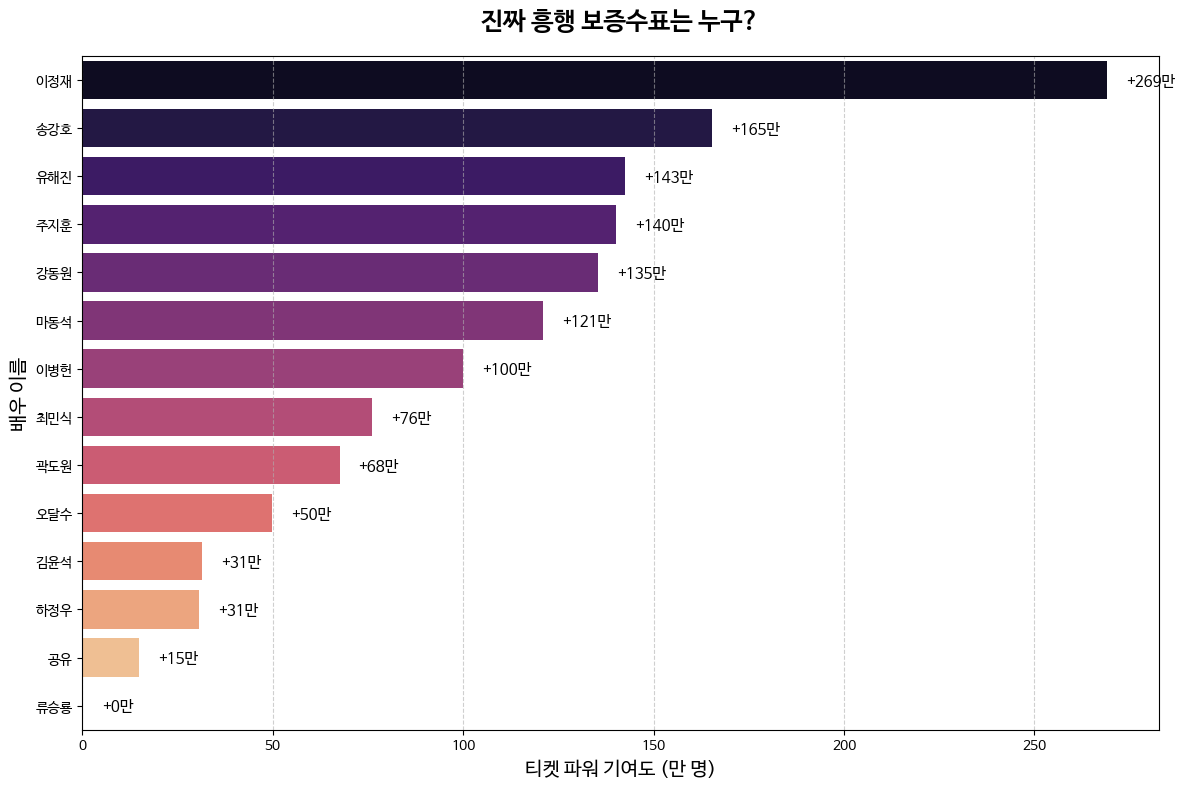

In [3]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

sys_font = fm.findSystemFonts()
nanum_font = [f for f in sys_font if 'Nanum' in f]
if nanum_font:
    font_name = fm.FontProperties(fname=nanum_font[0]).get_name()
    plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

file_path = 'top50_actors_boxoffice.csv'
df = pd.read_csv(file_path)
print(f"✅ 업로드된 파일에서 데이터 로딩 완료!\n")

df_clean = df[df['Audience'] > 0].copy()
df_clean['Actor'] = df_clean['Actor'].astype(str).str.strip() # 공백 완벽 제거
df_clean['Audience_man'] = df_clean['Audience'] / 10000

X = pd.get_dummies(df_clean[['Actor']])
y = df_clean['Audience_man']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import Lasso

# 심사 기준, alpha 값이 작을수록 심사 기준 넓어짐
model = Lasso(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    '배우': X.columns.str.replace('Actor_', ''),
    '티켓파워(만명)': model.coef_
})
survivors = coefficients[coefficients['티켓파워(만명)'] > 0].sort_values(by='티켓파워(만명)', ascending=False)

if survivors.empty:
    print("선택된 배우가 없습니다. (코드 중간의 alpha 값을 더 작게 줄여보세요!)")
else:
    print("--- 🎬 Lasso 회귀가 선택한 핵심 흥행 보증수표 배우 ---")
    for index, row in survivors.iterrows():
        print(f"🏆 {row['배우']} : +{row['티켓파워(만명)']:.0f}만 명")

    plt.figure(figsize=(12, 8))
    sns.barplot(x='티켓파워(만명)', y='배우', data=survivors, palette='magma')
    plt.title(f'진짜 흥행 보증수표는 누구?', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('티켓 파워 기여도 (만 명)', fontsize=14)
    plt.ylabel('배우 이름', fontsize=14)
    for index, value in enumerate(survivors['티켓파워(만명)']):
        plt.text(value + 5, index + 0.1, f"+{value:.0f}만", fontsize=11, color='black')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()